# Peramalan kadar $NO_2$ di daerah Bojonegoro

## Latar Belakang

Peningkatan aktivitas industri, transportasi, serta pertumbuhan populasi yang pesat telah menyebabkan peningkatan signifikan terhadap tingkat pencemaran udara di berbagai wilayah. Salah satu polutan udara utama yang menjadi perhatian adalah Nitrogen Dioksida (NO₂), yaitu gas beracun yang dihasilkan terutama dari proses pembakaran bahan bakar fosil seperti kendaraan bermotor, pembangkit listrik, dan kegiatan industri. NO₂ memiliki dampak serius terhadap kesehatan manusia, seperti gangguan pernapasan, iritasi paru-paru, serta memperburuk penyakit asma dan bronkitis. Selain itu, NO₂ juga berkontribusi terhadap pembentukan hujan asam dan penurunan kualitas lingkungan secara keseluruhan.

## 1. Pengumpulan Data

Pertama kita akan mengumpulkan data Time Series Harian kadar NO2 di daerah Bojonegoro. Pengumpulan data dari sumber website https://dataspace.copernicus.eu/ , buat akun terlebih dahulu di website copernicus tersebut. 

Dokumentasi cara pengambilan data di https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html .

Untuk menuliskan code Python untuk mengambil data, silahkan kunjungi halaman https://dataspace.copernicus.eu/analyse/jupyterlab, klik Access JupyterLab, scroll kebawah sedikit ..., lalu pilih Python 3 (ipykernel)

Disini kita akan mengambil data kadar NO2 di daerah Bojonegoro dari tanggal 2023-10-01 sampai 2025-10-01.

Kita install terlebih dahulu openeo:

In [ ]:
!pip install openeo

Lalu tuliskan code dibawah:

In [1]:
import openeo

In [2]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


pada saat menjalankan baris code diatas (connection), nanti akan diminta authentikasi seperti output berikut:

```
Terminal/Output
Visit (link authentikasi) 📋 to authenticate.
✅ Authorized successfully
Authenticated using device code flow.
```

Kalian tinggal klik link authentikasi lalu login menggunakan akun "copernicus" kalian.

In [3]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [111.8596709, -7.1154245],
            [111.6093957, -7.1154245],
            [111.6093957, -7.2272944],
            [111.8596709, -7.2272944],
            [111.8596709, -7.1154245],
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west": 111.6093957,
        "south": -7.2272944,
        "east": 111.8596709,
        "north": -7.1154245
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

Code diatas memerlukan titik koordinasi area yang akan diambil data $NO_2$-nya, untuk mengambil titik koordinasi kunjungi website https://geojson.io/#map=12/-7.1713/111.7345 . Didalam website tersebut kalian akan memilih daerah dengan cara memberi shape kotak didaerah yang ingin kalian ambil datanya.

Di panel sebelah kanan terdapat data JSON yang berupa koordinat daerah yang kalian pilih, kalian salin terus sesuaikan dengan code diatas di bagian variabel "aoi" dan spatial_extent.

Lalu kalian tambahkan baris code dibawah untuk memulai pengambilan data:

In [4]:
job = s5post.execute_batch(title="NO2 in Bojonegoro", outputfile="NO2Bojonegoro.nc")

0:00:00 Job 'j-26060307195148e292e1d2a0caed31cc': send 'start'
0:00:50 Job 'j-26060307195148e292e1d2a0caed31cc': queued (progress 0%)
0:00:59 Job 'j-26060307195148e292e1d2a0caed31cc': queued (progress 0%)
0:01:06 Job 'j-26060307195148e292e1d2a0caed31cc': queued (progress 0%)
0:01:14 Job 'j-26060307195148e292e1d2a0caed31cc': queued (progress 0%)
0:01:24 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:01:36 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:01:52 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:02:12 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:02:36 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:03:06 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:03:43 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:04:30 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:05:29 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N

Tunggu proses pengambilan data, output proses seperti berikut:

```
0:00:00 Job 'j-26060307195148e292e1d2a0caed31cc': send 'start'
0:00:50 Job 'j-26060307195148e292e1d2a0caed31cc': queued (progress 0%)
0:00:59 Job 'j-26060307195148e292e1d2a0caed31cc': queued (progress 0%)
0:01:06 Job 'j-26060307195148e292e1d2a0caed31cc': queued (progress 0%)
0:01:14 Job 'j-26060307195148e292e1d2a0caed31cc': queued (progress 0%)
0:01:24 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:01:36 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:01:52 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:02:12 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:02:36 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:03:06 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:03:43 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:04:30 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:05:29 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:06:29 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:07:30 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
0:08:30 Job 'j-26060307195148e292e1d2a0caed31cc': running (progress N/A)
...
0:09:31 Job 'j-26060307195148e292e1d2a0caed31cc': finished (progress 100%)
```

Abaikan ketika ada N/A.

Ketika proses pengambilan data, aktivitas kalian akan terekam di halaman https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2 . Disitu terdapat nama dataset dan status pengambilan data.

## 2. Preprocessing Data

Setelah kita mengambil data, data bisa diunduh di halaman https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2 . File akan berbentuk .nc. Kita cuman perlu kolom date dan NO2 menggunakan code dibawah:

In [5]:
import netCDF4

file_path = "data/openEO.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
print(len(no2))
print(len(no2[0]))
print(len(no2[0][0]))
print(no2[0][0][0])

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
726
4
5
2.3487672e-05


Dari code diatas kita mengetahui bentuk data dari kolom NO2 nya.

Untuk melihat 10 data pertama adalah:

In [6]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[2.3487671569455415e-05 4.054677265230566e-05 3.003061647177674e-05
  2.8549688067869283e-05 2.9555903893196955e-05]
 [4.6808931074338034e-05 4.054677265230566e-05 2.3878199499449693e-05
  3.3463431464042515e-05 2.9555903893196955e-05]
 [2.9249762519611977e-05 2.462200245645363e-05 2.3878199499449693e-05
  4.076754339621402e-05 4.076754339621402e-05]
 [2.9249762519611977e-05 3.142260175081901e-05 3.0169410820235498e-05
  3.0169410820235498e-05 4.080959115526639e-05]]
[[1.8213286239188164e-05 2.3665257685934193e-05 2.8048687454429455e-05
  1.9495668311719783e-05 3.0114006221992895e-05]
 [3.2921143429121e-05 1.7705448044580407e-05 2.786409095278941e-05
  3.0114006221992895e-05 3.0114006221992895e-05]
 [3.2921143429121e-05 3.8656344258924946e-05 2.786409095278941e-05
  3.795989687205292e-05 3.795989687205292e-05]
 [2.708628380787559e-05 3.8656344258924946e-05 3.978833046858199e-05
  3.795989687205292e-05 2.610431874927599e-05]]
[[3.518018274917267e-05 3.5180182749172

Dalam sehari, terdapat banyak data NO2, jadi kita rata-ratakan agar satu cell data hanya terdapat satu value. Namun terdapat masalah pada data NO2 seperti missing value.

### a. Mengatasi Missing Value menggunakan metode Interpolasi Linear

Sekarang kita akan mengatasi permasalahan missing value pada data NO2.

In [8]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):
    for j in range(no2.shape[2]):
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

Dengan code diatas, missing value yang terdapat pada data NO2 akan diisi secara otomatis menggunakan metode Interpolasi Linear.

### b. Rata-ratakan Data dan ubah Datetime

Setelah mengatasi missing value, kita akan me-rata-rata-kan data NO2 agar satu record hanya berupa single value. Sekalian kita mengambil date nya dan menaruh di array. Kita akan mengubah datetime dari awalnya (2023-10-04 00:00:00) menjadi (2023-10-04) karena kita mengambil data time series harian jadi kita tidak memerlukan data jam, menit dan detik.

In [9]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

### c. Simpan data dalam bentuk CSV

Setelah itu kita akan membentuk data menjadi DataFrame Pandas untuk disimpan menjadi CSV.

In [10]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Bojonegoro_timeseries.csv", index=False)
print(df.head())
print(df.info())

         date       NO2
0  2023-10-01  0.000032
1  2023-10-02  0.000030
2  2023-10-03  0.000045
3  2023-10-04  0.000047
4  2023-10-05  0.000036
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 726 entries, 0 to 725
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    726 non-null    object 
 1   NO2     726 non-null    float32
dtypes: float32(1), object(1)
memory usage: 8.6+ KB
None


Untuk mengatasi missing value dan menyimpan data ke CSV sudah berhasil.

### d. Pengecekan Missing Value data harian pada CSV

Sekarang setelah data berbentuk CSV, kita cek apakah data Time Series harian lengkap. Cara men-cek apakah data Time Series Harian lengkap gunakan code dibawah:

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Bojonegoro_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 5
Daftar tanggal missing:
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-23', '2025-01-30',
               '2025-01-31'],
              dtype='datetime64[ns]', freq=None)


Jika terdapat hari yang missing, kita akan mengatasi lagi missing value menggunakan metode Interpolasi Linear. Cara memperbaikinya gunakan code dibawah:

In [12]:
import pandas as pd

# Pastikan datetime dan sorting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2023-10-01", end="2025-09-30", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# (Opsional) jika masih ada NaN di bagian awal/akhir bisa gunakan forward/backward fill
df['NO2'] = df['NO2'].bfill().ffill()

# Simpan kembali ke CSV
df.to_csv("no2_bojonegoro_interpolated.csv")
print("Data setelah interpolasi:")
print(df.head())
print(df.info())

Data setelah interpolasi:
                 NO2
date                
2023-10-01  0.000032
2023-10-02  0.000030
2023-10-03  0.000045
2023-10-04  0.000047
2023-10-05  0.000036
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2023-10-01 to 2025-09-30
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NO2     731 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB
None


Cek ulang apakah masih ada missing value:

In [13]:
# Cek ulang missing value
missing_dates_check = full_range.difference(df.index)
print(f"Jumlah hari missing: {len(missing_dates_check)}")
print("Daftar tanggal missing:")
print(missing_dates_check)

Jumlah hari missing: 0
Daftar tanggal missing:
DatetimeIndex([], dtype='datetime64[ns]', name='date', freq='D')


Setelah dicek missing value harian, sudah tidak ada lagi missing value.

Dengan bentuk data terdapat 2 kolom, kolom pertama yaitu date atau tanggal, kolom kedua yaitu kadar NO2 yang sudah di rata-rata kan.

## 3. Modeling menggunakan KNN Regression

Dengan data Time Series kadar NO2 harian di daerah Bojonegoro, kita akan memprediksi kadar NO2 satu hari yang akan datang. Sekarang kita akan ubah data, mencoba mencari korelasi antara 1 hari dengan 4 hari sebelumnya. Kita juga akan membandingkan apakah semakin banyak hari sebelumnya, model akan lebih bagus?

### a. Normalisasi Data

Karena kita menggunakan model KNN Regression, maka perlu normalisasi data menggunakan Min-Max Scaler.

In [14]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

print(df.head())
print(df.info())

                 NO2  NO2_scaled
date                            
2023-10-01  0.000032    0.446936
2023-10-02  0.000030    0.398857
2023-10-03  0.000045    0.722477
2023-10-04  0.000047    0.763102
2023-10-05  0.000036    0.515276
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2023-10-01 to 2025-09-30
Freq: D
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   NO2         731 non-null    float64
 1   NO2_scaled  731 non-null    float64
dtypes: float64(2)
memory usage: 17.1 KB
None


Maka data akan di-normalisasi 0-1.

### b. Mengubah Data

Sekarang saya ingin mengubah data dari sebelumnya hanya 2 fitur menjadi 4 hari sebelum yang terdapat 5 fitur (t-4, t-3, t-2, t-1, dan t sebagai label), saya juga membuat data 10 hari sebelum untuk membandingkan apakah semakin banyak hari sebelum, semakin baik pula modelnya?

In [15]:
import pandas as pd

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()
    
    # Membuat fitur t-4 sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)
    
    # Label hari H
    df_supervised['NO2(t)'] = data
    
    # Hapus baris yang masih mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)
    
    return df_supervised

# contoh penggunaan
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

            NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
date                                                        
2023-10-05  0.446936  0.398857  0.722477  0.763102  0.515276
2023-10-06  0.398857  0.722477  0.763102  0.515276  0.653322
2023-10-07  0.722477  0.763102  0.515276  0.653322  0.544880
2023-10-08  0.763102  0.515276  0.653322  0.544880  0.419782
2023-10-09  0.515276  0.653322  0.544880  0.419782  0.827080
...              ...       ...       ...       ...       ...
2025-09-26  0.278250  0.573422  0.484549  0.229511  0.372995
2025-09-27  0.573422  0.484549  0.229511  0.372995  0.434784
2025-09-28  0.484549  0.229511  0.372995  0.434784  0.262205
2025-09-29  0.229511  0.372995  0.434784  0.262205  0.367300
2025-09-30  0.372995  0.434784  0.262205  0.367300  0.364150

[727 rows x 5 columns]
(727, 5)


Untuk membuat data 10 hari sebelum tinggal tambah code dibawah (ubah parameter n_lag).

In [16]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)
print(supervised_df10)
print(supervised_df10.shape)

            NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  \
date                                                                      
2023-10-11   0.446936  0.398857  0.722477  0.763102  0.515276  0.653322   
2023-10-12   0.398857  0.722477  0.763102  0.515276  0.653322  0.544880   
2023-10-13   0.722477  0.763102  0.515276  0.653322  0.544880  0.419782   
2023-10-14   0.763102  0.515276  0.653322  0.544880  0.419782  0.827080   
2023-10-15   0.515276  0.653322  0.544880  0.419782  0.827080  0.684238   
...               ...       ...       ...       ...       ...       ...   
2025-09-26   0.294733  0.223919  0.170132  0.098560  0.236930  0.275472   
2025-09-27   0.223919  0.170132  0.098560  0.236930  0.275472  0.278250   
2025-09-28   0.170132  0.098560  0.236930  0.275472  0.278250  0.573422   
2025-09-29   0.098560  0.236930  0.275472  0.278250  0.573422  0.484549   
2025-09-30   0.236930  0.275472  0.278250  0.573422  0.484549  0.229511   

            NO2(t-4)  NO

### Modeling dan Evaluation

Sekarang dari 2 data yang sudah kita rubah, kita train menggunakan model KNN Regression.

In [17]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur dan label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN Regressor
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 581 — Test Size: 146
RMSE: 0.077497
R² Score: 0.2555

=== KNN - 10 Hari Sebelumnya ===
Train Size: 576 — Test Size: 145
RMSE: 0.074581
R² Score: 0.3147


### Plotting

Plotting untuk visualisasi grafik antara label dan prediksi dari kedua data diatas.

4 hari sebelum:

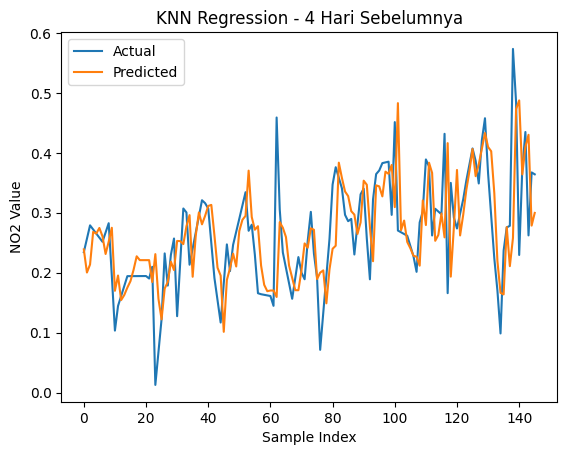

In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

10 hari sebelum:

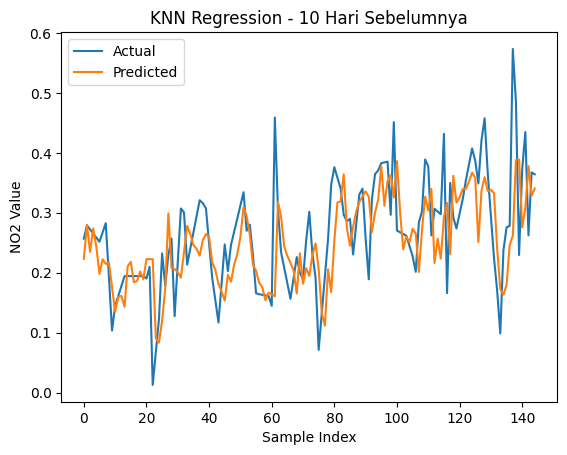

In [19]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

## Kesimpulan

Berdasarkan hasil pengujian model KNN Regression terhadap dua skenario jumlah fitur, yaitu 4 hari sebelumnya dan 10 hari sebelumnya, dapat disimpulkan bahwa penambahan jumlah fitur berupa lag harian tidak selalu meningkatkan kinerja model. Pada kasus data konsentrasi NO₂ di daerah Bojonegoro ini, model dengan 4 hari sebelumnya justru menunjukkan performa yang lebih baik dengan nilai RMSE lebih kecil dan R² yang lebih tinggi dibandingkan model dengan 10 hari sebelumnya. Hal ini mengindikasikan bahwa pola perubahan NO₂ lebih dipengaruhi oleh kondisi dalam beberapa hari terakhir, sehingga penambahan data historis yang terlalu jauh dapat menimbulkan noise dan mengurangi kemampuan model dalam mengenali pola. Selain itu, KNN merupakan metode berbasis kedekatan jarak yang cenderung mengalami penurunan performa ketika jumlah fitur bertambah karena curse of dimensionality. Dengan demikian, penggunaan 4 fitur (4 hari sebelumnya) lebih efektif dalam memodelkan data ini dibandingkan penggunaan 10 fitur.